In [11]:
import pandas as pd
import numpy as np
import sys
import os
import seaborn as sns
from Bio.PDB import PDBParser
from structools import * # Importamos tus herramientas
from aminotools import *
from Bio.PDB.SASA import ShrakeRupley # Para evitar el error de MSMS en Windows
import matplotlib.pyplot as plt

In [2]:
def get_surface_residues(structure, threshold=5, include_distance=False, include_resname=False):
    surface_matrix = GetRDSurface(structure[0])  # Get Residue Depth's Surface Model
    residues = get_residues(structure)           # Get Structure's Residues
    surface = []
    for res in residues:
        dist = min_dist(res.center_of_mass(), surface_matrix)
        if dist <= threshold: 
            res_id = f"{res.resname}{res.id[1]}{res.parent.id}"
            if not include_resname:  res_id = res_id.replace(res.resname, "")
            if include_distance: res_id = [res_id, dist]
            surface.append(res_id)  
    return surface

In [4]:
structure = get_structure("7uv0.pdb")

## Residuos del sitio activo

In [5]:
# Obtener residuos a 6 Å del ligando Ioduro
site = get_active_site(structure, ligands_names=["IOD"], threshold=6)
print(site)

{'703A': ['72A', '90A', '293A']}


### Entonces 703 es el residuo que se une al ligando Ioduro y el 72A, 90A y 293A se encuentran a una distancia de 6A

In [6]:
# Obtener residuos a 6 Å del ligando Sodio 
site = get_active_site(structure, ligands_names=["NA"], threshold=6)
print(site)

{'702A': ['67A', '69A', '71A', '72A', '144A'], '701A': ['72A', '413A', '416A', '417A']}


### Idem, pero acá hay dos ligandos de sodio 

## Residuos de superficie

In [7]:
surface_residues = get_surface_residues(structure, threshold=5)
print(surface_residues)

/home/fran/.local/lib/python3.10/site-packages/Bio/PDB/ResidueDepth.py:490: BiopythonWarning: I:IOD not in radii library.
  warnings.warn(f"{at_name}:{resname} not in radii library.", BiopythonWarning)


['10A', '11A', '12A', '13A', '14A', '15A', '16A', '17A', '18A', '19A', '20A', '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A', '31A', '32A', '33A', '34A', '35A', '36A', '56A', '57A', '58A', '59A', '60A', '61A', '62A', '63A', '65A', '66A', '67A', '68A', '69A', '74A', '75A', '78A', '79A', '81A', '82A', '83A', '85A', '86A', '88A', '89A', '91A', '92A', '93A', '95A', '96A', '98A', '99A', '100A', '102A', '103A', '104A', '105A', '106A', '107A', '108A', '110A', '111A', '112A', '113A', '114A', '115A', '116A', '119A', '122A', '123A', '124A', '125A', '126A', '127A', '128A', '129A', '130A', '131A', '132A', '133A', '134A', '135A', '136A', '137A', '138A', '139A', '140A', '141A', '142A', '144A', '145A', '147A', '148A', '149A', '150A', '154A', '156A', '157A', '158A', '159A', '160A', '161A', '162A', '163A', '164A', '165A', '166A', '167A', '168A', '169A', '170A', '171A', '172A', '173A', '174A', '175A', '176A', '177A', '178A', '179A', '180A', '181A', '182A', '183A', '190A', '191A', '

## Residuos del core

In [9]:
# Obtener todos los residuos con nombre + número + cadena (ej: 'GLU45A')
all_residues = [f"{res.resname}{res.id[1]}{res.parent.id}" for res in get_residues(structure)]

# Superficie
surface_residues = get_surface_residues(structure, threshold=5, include_resname=True)

# Sitio activo alrededor de IOD y NA
site_IOD = get_active_site(structure, ligands_names=["IOD"], threshold=6, include_resname=True)
site_NA = get_active_site(structure, ligands_names=["NA"], threshold=6, include_resname=True)

# Unir todos los residuos del sitio activo en una sola lista
active_site_residues = []
for lst in site_IOD.values():
    active_site_residues.extend(lst)
for lst in site_NA.values():
    active_site_residues.extend(lst)

# Convertir a conjuntos
set_all = set(all_residues)
set_surface = set(surface_residues)
set_active = set(active_site_residues)

# Obtener el core: todos menos superficie y sitio activo
core_residues = list(set_all - set_surface - set_active)

# Resultado
print("Residuos del core (núcleo):")
print(core_residues)

Residuos del core (núcleo):
['SER257A', 'TYR259A', 'ALA151A', 'VAL266A', 'THR117A', 'LEU282A', 'MET325A', 'ALA296A', 'ALA278A', 'VAL76A', 'LEU121A', 'VAL401A', 'TYR118A', 'GLN94A', 'VAL445A', 'PHE87A', 'PRO152A', 'PHE109A', 'ASN97A', 'LEU524A', 'TYR242A', 'ALA80A', 'PHE431A', 'MET435A', 'GLY425A', 'VAL419A', 'VAL73A', 'SER456A', 'LEU344A', 'TYR269A', 'LEU143A', 'GLY527A', 'ALA64A', 'VAL261A', 'PRO426A', 'ALA430A', 'ALA153A', 'ALA70A', 'GLY84A', 'TYR120A', 'LEU427A', 'PHE202A', 'PRO326A', 'PRO77A', 'PHE247A', 'LEU289A', 'GLY421A', 'SER424A', 'TRP255A', 'VAL254A', 'THR534A', 'THR101A', 'GLY146A', 'LEU352A', 'ILE155A', 'GLY260A', 'GLY251A', 'LEU328A']


In [18]:
# 1. Todos los residuos
all_residues = [f"{res.resname}{res.id[1]}{res.parent.id}" for res in get_residues(structure)]

# 2. Superficie
surface_residues = get_surface_residues(structure, threshold=6, include_resname=True)

# 3. Sitio activo (IOD y NA)
site_IOD = get_active_site(structure, ligands_names=["IOD"], threshold=6, include_resname=True)
site_NA = get_active_site(structure, ligands_names=["NA"], threshold=6, include_resname=True)

# Unir todos los residuos del sitio activo
active_site_residues = []
for lst in site_IOD.values():
    active_site_residues.extend(lst)
for lst in site_NA.values():
    active_site_residues.extend(lst)

# Convertir a sets (elimina duplicados automágicamente)
set_all = set(all_residues)
set_surface = set(surface_residues)
set_active = set(active_site_residues)

# El core: los que no están en superficie ni en el sitio activo
set_core = set_all - set_surface - set_active

# 🧮 Conteo
print(f"Total de residuos     : {len(set_all)}")
print(f"Residuos de superficie: {len(set_surface)}")
print(f"Residuos en sitio activo (IOD y NA): {len(set_active)}")
print(f"Residuos del core     : {len(set_core)}")

# Verificación
total_clasificados = len(set_surface | set_active | set_core)
print(f"\n¿Coincide con el total?: {total_clasificados == len(set_all)}")

Total de residuos     : 501
Residuos de superficie: 474
Residuos en sitio activo (IOD y NA): 10
Residuos del core     : 25

¿Coincide con el total?: True


# Armar dataframe

In [21]:
# 5. Crear listas etiquetadas
data = []

for res in surface_residues:
    data.append((res, "superficie"))
for res in active_site_residues:
    data.append((res, "sitio activo"))
for res in core_residues:
    data.append((res, "core"))

# 6. Crear DataFrame
df = pd.DataFrame(data, columns=["Residuo", "Categoría"])

# Opcional: ordenar por cadena/número
df = df.sort_values("Residuo").reset_index(drop=True)

# Mostrar resumen
print(df.head())
print("\nConteo por categoría:")
print(df["Categoría"].value_counts())

   Residuo   Categoría
0  ALA102A  superficie
1   ALA10A  superficie
2  ALA128A  superficie
3  ALA140A  superficie
4   ALA14A  superficie

Conteo por categoría:
Categoría
superficie      474
core             58
sitio activo     12
Name: count, dtype: int64


In [22]:
df.to_csv("residuos_clasificados.csv", index=False)

#----------------------------------------------------

### Clasificacion de las tres estructuras 

In [7]:
def obtener_limites_membrana(pdb_path):
    """Usa los atomos DUM de OPM para encontrar el cinturon de lipidos"""
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("opm", pdb_path)
    # Extraemos Z de los atomos cuyo padre se llame DUM
    z_coords = [atom.get_coord()[2] for atom in struct.get_atoms() 
                if "DUM" in atom.get_parent().get_resname()]
    if not z_coords: return -15.0, 15.0
    return min(z_coords), max(z_coords)

def calcular_superficie_windows(pdb_path):
    """Alternativa a get_surface() que no requiere instalar MSMS"""
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("mol", pdb_path)
    sr = ShrakeRupley()
    sr.compute(struct, level="R")
    # Si el area expuesta es > 2.5 A^2, es superficie
    return {f"{res.id[1]}{res.get_parent().id}" for res in struct.get_residues() if res.sasa > 2.5}

def procesar_nis(pdb_file):
    print(f"\n--- Procesando {pdb_file} ---")
    
    # A. Limites de Z (Membrana)
    z_min, z_max = obtener_limites_membrana(pdb_file)
    print(f"Zona de Membrana (Z): {z_min:.2f} a {z_max:.2f}")
    
    # B. Estructura via PDBParser (Requerido por los modulos de clasificacion de structools)
    struct_p = get_structure(pdb_file, src="PDBParser")
    
    # C. Sitio Activo (NA e IOD) usando structools
    # get_active_site devuelve un dict: {'701A': ['72A', '413A', ...]}
    site_na = get_active_site(struct_p, ligands_names=["NA"], threshold=6)
    site_iod = get_active_site(struct_p, ligands_names=["IOD"], threshold=6)
    
    # Unificamos IDs del sitio activo
    ids_sitio = set()
    for lista in list(site_na.values()) + list(site_iod.values()):
        for r_id in lista: ids_sitio.add(r_id)
        
    # D. Superficie Real (SASA)
    ids_superficie = calcular_superficie_windows(pdb_file)
    
    # E. Clasificacion Final
    data = []
    # Usamos get_residues de structools para iterar
    for res in get_residues(struct_p):
        res_id = f"{res.id[1]}{res.parent.id}"
        z_coord = res.center_of_mass()[2]
        
        # JERARQUIA DE ETIQUETAS
        if res_id in ids_sitio:
            cat = "Sitio activo"
        elif z_min <= z_coord <= z_max:
            # Si esta en el cinturon de la membrana, es CORE (protegido por lipidos)
            cat = "Core"
        elif res_id in ids_superficie:
            # Solo es superficie si esta fuera del cinturon Z y expuesto al agua
            cat = "Superficie"
        else:
            cat = "Core"
            
        # Formateamos el nombre (Ej: ALA102A)
        res_name_3 = res.resname
        data.append((f"{res_name_3}{res_id}", cat))
        
    df = pd.DataFrame(data, columns=["Residuo", "Categoría"])
    return df

In [ ]:
# --- EJECUCION PARA LAS 3 DE RATON ---
estructuras = ["7uuy", "7uuz", "7uv0"]

for est in estructuras:
    archivo = f"{est}Membrane.pdb"
    if os.path.exists(archivo):
        df_res = procesar_nis(archivo)
        output = f"residuos_clasificados_{est}.csv"
        df_res.to_csv(output, index=False)
        print(f"✅ ¡Listo! {output} generado.")
        print(df_res["Categoría"].value_counts())
    else:
        print(f"❌ No encontre el archivo {archivo}")


--- Procesando 7uuyMembrane.pdb ---
Zona de Membrana (Z): -15.20 a 15.20
✅ ¡Listo! residuos_clasificados_7uuy.csv generado.
Categoría
Core          341
Superficie    162
Name: count, dtype: int64

--- Procesando 7uuzMembrane.pdb ---
Zona de Membrana (Z): -15.90 a 15.90
✅ ¡Listo! residuos_clasificados_7uuz.csv generado.
Categoría
Core            351
Superficie      146
Sitio activo      4
Name: count, dtype: int64

--- Procesando 7uv0Membrane.pdb ---
Zona de Membrana (Z): -15.80 a 15.80
✅ ¡Listo! residuos_clasificados_7uv0.csv generado.
Categoría
Core            349
Superficie      142
Sitio activo     10
Name: count, dtype: int64


## Gráficos 

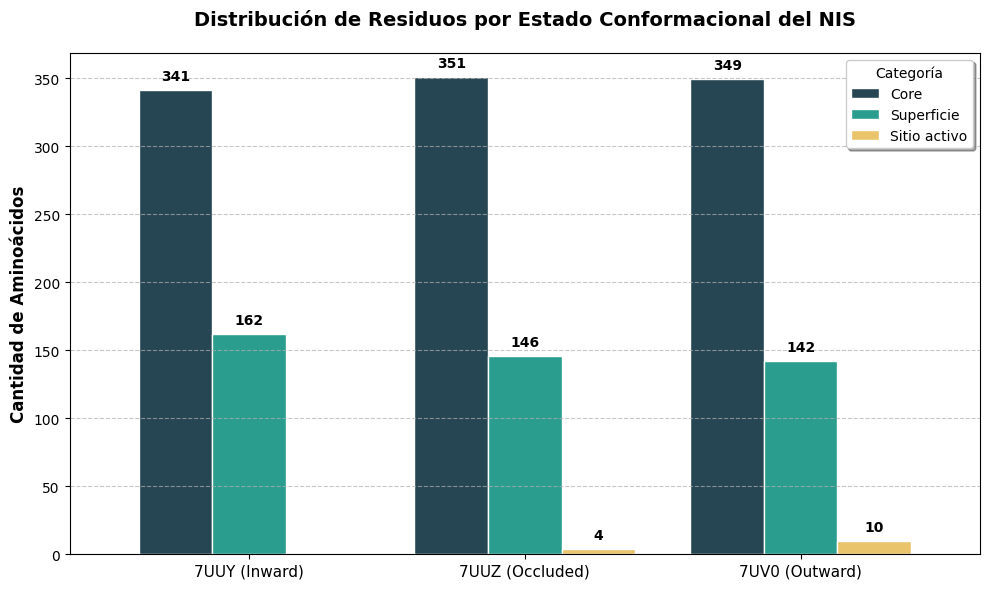

In [ ]:
# 1. Lista de tus archivos y nombres para el gráfico
archivos = ["residuos_clasificados_7uuy.csv", 
            "residuos_clasificados_7uuz.csv", 
            "residuos_clasificados_7uv0.csv"]

nombres_estados = ["7UUY (Inward)", "7UUZ (Occluded)", "7UV0 (Outward)"]

# 2. Leer los datos y contar categorías
conteos = []
for f in archivos:
    df = pd.read_csv(f)
    # .value_counts() cuenta cuántos hay de cada etiqueta
    vc = df['Categoría'].value_counts()
    
    # Guardamos los resultados asegurándonos de que si no existe la categoría, valga 0
    conteos.append({
        'Core': vc.get('Core', 0),
        'Superficie': vc.get('Superficie', 0),
        'Sitio activo': vc.get('Sitio activo', 0)
    })

# Convertimos todo a un DataFrame para plotear fácil
df_plot = pd.DataFrame(conteos, index=nombres_estados)

# 3. Configuración del gráfico
# Colores: Azul Petróleo (Core), Esmeralda (Superficie), Ámbar (Sitio Activo)
colores = ['#264653', '#2A9D8F', '#E9C46A']

ax = df_plot.plot(kind='bar', figsize=(10, 6), color=colores, edgecolor='white', width=0.8)

# Títulos y etiquetas
plt.title('Distribución de Residuos por Estado Conformacional del NIS', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Cantidad de Aminoácidos', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Categoría', frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Agregar los números arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.tight_layout()  

# Pa pintarlo en VMD

In [5]:
import pandas as pd
import sys
import os
from Bio.PDB import PDBParser, PDBIO
from Bio.PDB.SASA import ShrakeRupley

# 1. Configuración de Rutas
ruta_repo = r"C:\Users\fran_\Documents\Doctorado\bioinfo-tools"
if ruta_repo not in sys.path:
    sys.path.append(ruta_repo)

from structools import get_structure, get_active_site, get_residues

# --- TUS FUNCIONES DEFINIDAS ---

def obtener_limites_membrana(pdb_path):
    """Usa los atomos DUM de OPM para encontrar el cinturon de lipidos"""
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("opm", pdb_path)
    z_coords = [atom.get_coord()[2] for atom in struct.get_atoms() 
                if "DUM" in atom.get_parent().get_resname()]
    if not z_coords: return -15.0, 15.0
    return min(z_coords), max(z_coords)

def calcular_superficie_windows(pdb_path):
    """Alternativa a get_surface() que no requiere instalar MSMS"""
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("mol", pdb_path)
    sr = ShrakeRupley()
    sr.compute(struct, level="R")
    return {f"{res.id[1]}{res.get_parent().id}" for res in struct.get_residues() if res.sasa > 2.5}

def procesar_nis_y_etiquetar(pdb_file, id_est):
    print(f"\n🚀 Iniciando proceso para: {pdb_file}")
    
    # A. Análisis previo (Z y SASA)
    z_min, z_max = obtener_limites_membrana(pdb_file)
    ids_superficie = calcular_superficie_windows(pdb_file)
    
    # B. Estructura via PDBParser (Objeto para manipular y guardar)
    struct_p = get_structure(pdb_file, src="PDBParser")
    
    # C. Sitio Activo
    site_na = get_active_site(struct_p, ligands_names=["NA"], threshold=6)
    site_iod = get_active_site(struct_p, ligands_names=["IOD"], threshold=6)
    ids_sitio = set([r for lista in list(site_na.values()) + list(site_iod.values()) for r in lista])
    
    # D. Clasificación e inyección de B-factor
    # 1.0 = Core | 2.0 = Superficie | 3.0 = Sitio activo
    resumen_data = []
    
    for res in get_residues(struct_p):
        res_id = f"{res.id[1]}{res.parent.id}"
        z_coord = res.center_of_mass()[2]
        
        if res_id in ids_sitio:
            cat_nombre = "Sitio activo"
            b_val = 3.0
        elif z_min <= z_coord <= z_max:
            cat_nombre = "Core"
            b_val = 1.0
        elif res_id in ids_superficie:
            cat_nombre = "Superficie"
            b_val = 2.0
        else:
            cat_nombre = "Core"
            b_val = 1.0
            
        # Guardamos en la tabla
        resumen_data.append((f"{res.resname}{res_id}", cat_nombre))
        
        # Inyectamos el valor en cada átomo para el PDB final
        for atom in res:
            atom.set_bfactor(b_val)

    # E. Guardado de archivos
    # 1. El CSV
    df = pd.DataFrame(resumen_data, columns=["Residuo", "Categoría"])
    df.to_csv(f"residuos_clasificados_{id_est}.csv", index=False)
    
    # 2. El PDB Etiquetado
    io = PDBIO()
    io.set_structure(struct_p)
    io.save(f"{id_est}_etiquetado.pdb")
    
    print(f"✅ Finalizado {id_est}: CSV y PDB generados.")
    print(df["Categoría"].value_counts())

In [10]:
# --- EJECUCION PARA EL MODELO DE ALPHA_FOLD (HUMANO) ---
archivo_af = "AF-Q92911model.pdb"
id_est = "AF_Human" # Nombre cortito para el CSV y el PDB etiquetado

if os.path.exists(archivo_af):
    # Usamos la funcion maestra que genera el CSV y el PDB con B-factors
    procesar_nis_y_etiquetar(archivo_af, id_est)
    
    print(f"\n✅ Proceso terminado para el modelo Humano.")
    print(f"Archivos generados: residuos_clasificados_{id_est}.csv y {id_est}_etiquetado.pdb")
else:
    print(f"❌ No encontre el archivo {archivo_af} en el directorio actual.")
    # Tip: fijate si el nombre es exactamente ese o si le falta el .pdb


🚀 Iniciando proceso para: AF-Q92911model.pdb
✅ Finalizado AF_Human: CSV y PDB generados.
Categoría
Core          398
Superficie    245
Name: count, dtype: int64

✅ Proceso terminado para el modelo Humano.
Archivos generados: residuos_clasificados_AF_Human.csv y AF_Human_etiquetado.pdb


In [6]:
# --- EJECUCIÓN PARA LAS 3 ESTRUCTURAS ---
estructuras = ["7uuy", "7uuz", "7uv0"]

for est in estructuras:
    nombre_archivo = f"{est}Membrane.pdb"
    if os.path.exists(nombre_archivo):
        procesar_nis_y_etiquetar(nombre_archivo, est)
    else:
        print(f"⚠️ No se encontró {nombre_archivo}")


🚀 Iniciando proceso para: 7uuyMembrane.pdb


c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 2, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 3, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 4, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 5, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy i

✅ Finalizado 7uuy: CSV y PDB generados.
Categoría
Core          341
Superficie    162
Name: count, dtype: int64

🚀 Iniciando proceso para: 7uuzMembrane.pdb


c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 2, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 3, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 4, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 5, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy i

✅ Finalizado 7uuz: CSV y PDB generados.
Categoría
Core            351
Superficie      146
Sitio activo      4
Name: count, dtype: int64

🚀 Iniciando proceso para: 7uv0Membrane.pdb
✅ Finalizado 7uv0: CSV y PDB generados.
Categoría
Core            349
Superficie      142
Sitio activo     10
Name: count, dtype: int64


c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 2, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 3, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 4, ' '), ('N', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy in atom ('model', 0, 'p', ('H_DUM', 5, ' '), ('O', ' ')) written as blank
  warnings.warn(
c:\Users\fran_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\Bio\PDB\PDBIO.py:249: PDBIOWarning: Missing occupancy i

# Pa pintar en PyMol 


In [2]:
def generar_script_pymol(csv_file, output_pml):
    df = pd.read_csv(csv_file)
    
    with open(output_pml, 'w') as f:
        # 1. Definimos los colores (usando los mismos del grafico)
        f.write("set_color core_color, [38, 70, 83]\n")      # Azul Petroleo
        f.write("set_color surf_color, [42, 157, 143]\n")    # Verde Esmeralda
        f.write("set_color site_color, [233, 196, 106]\n")   # Ambar
        
        # 2. Reseteamos la vista
        f.write("color gray80, all\n")
        
        # 3. Pintamos por categoria
        for _, row in df.iterrows():
            # Extraemos el numero y la cadena del residuo (ej: ALA102A -> resi 102, chain A)
            res_full = row['Residuo']
            # El numero esta entre el nombre (3 letras) y la cadena (ultima letra)
            res_num = res_full[3:-1] 
            chain = res_full[-1]
            categoria = row['Categoría']
            
            if categoria == "Core":
                color = "core_color"
            elif categoria == "Superficie":
                color = "surf_color"
            else: # Sitio activo
                color = "site_color"
                # Al sitio activo le damos un estilo mas gordo para que se vea
                f.write(f"show spheres, resi {res_num} and chain {chain}\n")
            
            f.write(f"color {color}, resi {res_num} and chain {chain}\n")
            
        f.write("show cartoon\n")
        f.write("set transparency, 0.5, resi 1-1000\n") # Un poco de transparencia al resto
        f.write("util.cnc\n") # Colorear atomos de nitrogeno y oxigeno tipicos

    print(f"✅ Script generado: {output_pml}")

# Generamos uno para la 7UV0 que es la que tiene mas sitio activo
generar_script_pymol("residuos_clasificados_7uv0.csv", "pintar_7uv0.pml")

✅ Script generado: pintar_7uv0.pml


# Graficos integradores 

C:\Users\fran_\AppData\Local\Temp\ipykernel_2688\2247507565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Estructura_Consenso', y='ddG_7UV0', palette='Set2')


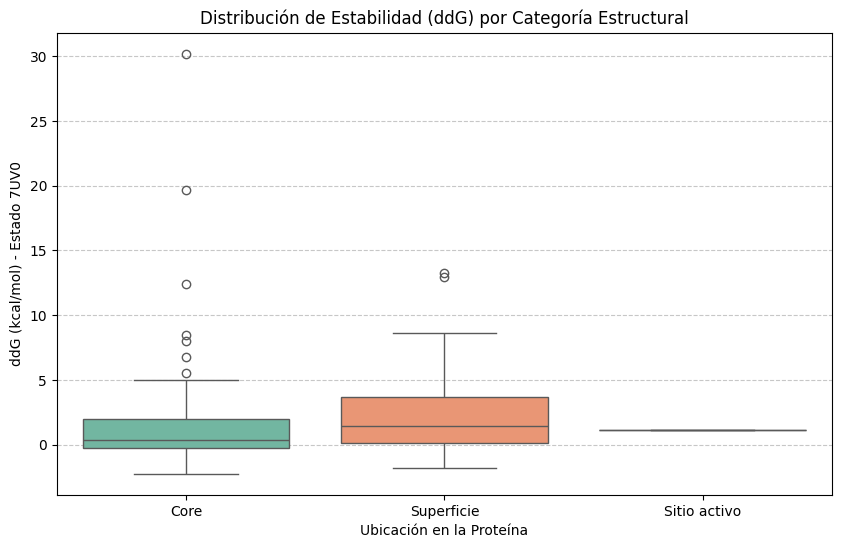

In [13]:
# Cargamos el archivo
df = pd.read_csv("Tabla_CompletaV0.csv")

# Graficamos el ddG vs la Categoría de Consenso
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Estructura_Consenso', y='ddG_7UV0', palette='Set2')
plt.title('Distribución de Estabilidad (ddG) por Categoría Estructural')
plt.ylabel('ddG (kcal/mol) - Estado 7UV0')
plt.xlabel('Ubicación en la Proteína')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()